# Maximizing Performance

Checkpointing performance is a core focus of the Orbax team and we strive to make our library as performant out-of-the-box as possible. However, many performance features are tailored for more specific use cases and are usable on
an opt-in basis.

When we say "performance" with regards to checkpointing, we generally have a few primary metrics:


*   **Save blocking time:** The time spent blocking the main thread. In an async save, this is largely attributable to the device/host transfer bandwidth (e.g. 32 GB/s with TPU PCIe Gen5) and is minimally attributable to Orbax.
*   **Save total time:** The total time required to save a checkpoint completely. Since the majority of the total time is comprised of disk I/O occuring in a background thread, its performance impact is less obvious. However, we still want to ensure reliably fast checkpoint completions, as frequent checkpointing can [increase overall training goodput](https://developers.googleblog.com/boost-training-goodput-how-continuous-checkpointing-optimizes-reliability-in-orbax-and-maxtext/).
*   **Load total time:** The total time required to load a checkpoint. This is critical for warmstart training, evaluations, and inference. It impacts accelerator utilization, experiment recovery times, and developer velocity. While loads are performed less frequently than saves, their blocking nature makes them more critical.
*   **Memory consumption:** The additional RAM consumed by checkpointing. RAM is a scarce resource just as accelerators are and excess memory consumed by checkpointing inhibits other useful applications of available memory.



Below, we will reference various performance benchmarks. These are performed with single- or multi-region GCS buckets using Llama 3.1 models (8B, 70B, and 405B) adapted for JAX
using [MaxText](https://maxtext.readthedocs.io/). Typically, we use TPU topologies v5p-8, v5p-32, and v5p-128 for each model size, respectively, unless otherwise noted.

In [ ]:
import jax
from jax import numpy as jnp
from orbax.checkpoint import v1 as ocp
import os
import numpy as np
from etils import epath

# Use 16 fake devices.
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=16"
root_directory = epath.Path('/tmp/maximizing_performance')
root_directory.rmtree(missing_ok=True)

## Key Performance Optimizations

### Asynchronous Checkpointing

Async checkpointing is THE key checkpointing performance improvement, as it can hide almost all of the cost of slow disk I/O behind training computations. It is strongly recommended that all users should enable this feature. See our [guide](https://orbax.readthedocs.io/en/latest/guides/checkpoint/v1/async_checkpointing.html) for more details.

### Storage Format

Orbax provides two [storage formats](https://orbax.readthedocs.io/en/latest/guides/checkpoint/v1/checkpoint_format.html#pytree-checkpointables) (leveraging [TensorStore](https://google.github.io/tensorstore/)) referred to as `OCDBT` and `non-OCDBT`.

At a high level, the `non-OCDBT` format stores each model weight as a separate directory while the `OCDBT` format packs model weights into a series of uniform files.


#### `OCDBT` Format
This format packs model weights into a series of uniform files.

<font color="green">**+++**</font>

*   Improved performance for large models.
*   More tunable settings for extracting performance on different filesystems.

<font color="red">**---**</font>

*   Higher overhead, poorer performance for small models.

#### `non-OCDBT` Format
This format stores each model weight as a separate sub-directory.

<font color="green">**+++**</font>

*   More human-readable.
*   Low-overhead on small models.

<font color="red">**---**</font>

*   Performs poorly for models with many distinct arrays (especially small arrays).
*   Poorer performance for large models.

| Operation | Model | Topology | OCDBT | No OCDBT | Speedup |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Load | 8B | v5p-8 | 22.85 ± 4.68 | 17.97 ± 4.22 | 0.79×* |
| Load | 70B | v5p-32 | 41.19 ± 4.17 | 40.04 ± 4.61 | 0.97× |
| Load | 405B | v5p-128| 59.14 ± 4.06 | 65.18 ± 12.01 | **1.10×** |
| Save (Background) | v5p-8 | 8B | 59.37 ± 9.04 | 33.71 ± 3.20 | 0.57×* |
| Save (Background) | v5p-32 | 70B | 62.47 ± 9.09 | 80.84 ± 8.82 | **1.29×** |
| Save (Background) | v5p-64 | 405B | 91.76 ± 14.91 | 123.33 ± 19.27 | **1.34×** |

You can configure the storage format following this example:

In [ ]:
ctx = ocp.Context()
ctx.array.saving.use_ocdbt = True  # default
with ctx:
  path = root_directory / 'ckpt_ocdbt'
  ocp.save(path, {'a': jnp.arange(8)})
  assert os.path.exists(path / 'state' / 'manifest.ocdbt')

ctx.array.saving.use_ocdbt = False
with ctx:
  path = root_directory / 'ckpt_non_ocdbt'
  ocp.save(path, {'a': jnp.arange(8)})
  assert not os.path.exists(path / 'state' / 'manifest.ocdbt')

### Loading with Resharding

When warm-starting or recovering a training experiment, or when performing evaluations or inference on a different topology than the training topology, *resharding* is needed.

To facilitate efficient (fast and low-memory-overhead) checkpoint loading with resharding, we need to first understand a bit about how Orbax uses TensorStore to store large distributed arrays.

Using TensorStore's zarr driver, distributed arrays are represented in a chunked format, where `jax.Array` shards correspond one-to-one with TensorStore shards. If an array is resharded and its new boundaries don't align with the originally saved chunks, the system is forced to load and discard excess data, which increases I/O and memory (RAM) overhead.

However, we can subdivide larger write chunks by configuring granular "subchunks" at save time, which reduces overhead.

This is illustrated in the figure below. For example, if our array is shape `(4, 4)`, it may be sharded across 4 devices using shard shapes of `(2, 2)`. The checkpoint will be saved with chunks of the same shape.

If we attempt a reshard operation where we need to load shards of shape `(1, 2)`, each read will have 2x overhead, since the `(2, 2)` chunk is the smallest readable unit.

This can be resolved if we configure `(1, 1)` chunk shapes though, as a `(1, 2)` will read two chunks with no overhead.

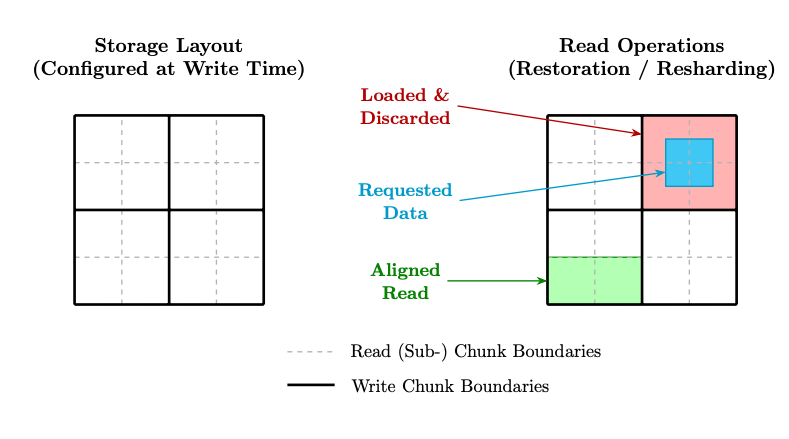

The chief drawback of this feature is that it must be specified at **save** time, meaning that you must have some insight into the various ways in which the checkpoint will be loaded with resharding in order to optimize.

If such patterns are not known in advance, or are variable depending on the use case, it is still valuable to specify a `chunk_byte_size` 10MB or greater.

The `StorageOptions` config can be used to limit the size of chunks. This
config can apply to all arrays globally, or can be used with `scoped_storage_options_creator` to apply differently to individual weights.

In [ ]:
import inspect

doc = inspect.getdoc(ocp.options.ArrayOptions.Saving.StorageOptions)
print(doc)

In the following example, we limit the chunk byte size to 16 bytes. For a 128-element array sharded across 16 devices, the shard shape (called `write_shape` below) is `(8,)`. Limited to 16 bytes, the shape becomes `(4,)`, as you see below with `chunk_shape`.

In [ ]:
arr = jnp.ones(
    (128,),  # 128 * 4 bytes
    device=jax.sharding.NamedSharding(
       jax.sharding.Mesh(jax.devices(), ('x',)),
       jax.sharding.PartitionSpec('x'),
    )
)

In [ ]:
ctx = ocp.Context()
with ctx:
  path = root_directory / 'ckpt_not_subchunked'
  ocp.save(path, {'a': arr}, overwrite=True)
ocp.metadata(path).metadata['a'].storage_metadata

In [ ]:
ctx = ocp.Context()
ctx.array.saving.storage_options.chunk_byte_size = 16
with ctx:
  path = root_directory / 'ckpt_subchunked'
  ocp.save(path, {'a': arr}, overwrite=True)
ocp.metadata(path).metadata['a'].storage_metadata

Let's imagine our model has the following (32, 32) array, with shard shapes of (4, 16):

In [ ]:
arr = jnp.ones(
    (32, 32),
    device=jax.sharding.NamedSharding(
       jax.sharding.Mesh(np.array(jax.devices()).reshape(8, 2), ('x', 'y')),
       jax.sharding.PartitionSpec('x', 'y')
    )
)

In [ ]:
arr.sharding.shard_shape(arr.shape)

Now let's suppose we want to load it with the following sharding, giving a shard shape of (32, 2):

In [ ]:
sharding = jax.sharding.NamedSharding(
    jax.sharding.Mesh(np.array(jax.devices()).reshape(1, 16), ('x', 'y')),
    jax.sharding.PartitionSpec(None, 'y')
)
sharding.shard_shape(arr.shape)

Without subchunking, in order to read a single shard of shape (32, 2), we would have to read all 16 columns in the origin chunk, discarding 14, in order to obtain the 2 we actually want.

To fix this, we can ensure that our checkpoint is saved with sub-chunking along the column dimension. Now the `chunk_shape` becomes `(4, 1)` while `write_shape` (the original shard shape) remains the same.

In [ ]:
ctx = ocp.Context()
ctx.array.saving.storage_options.chunk_byte_size = 16
ctx.array.saving.storage_options.shard_axes = (1,)

with ctx:
  path = root_directory / 'ckpt_subchunked_with_shard_axes'
  ocp.save(path, {'a': arr}, overwrite=True)  # 32 * 32 * 4 bytes
ocp.metadata(path).metadata['a'].storage_metadata

A large-scale performance evaluation of this feature on Llama 3.1 70B model shows positive results for various resharding patterns, as shown below.

| Model | Origin Topology | Sharding (data, fsdp, tensor) | Target Topology | Sharding (data, fsdp, tensor) | Subchunked | Not Subchunked | Speedup |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Llama 3.1 70B | v5p-256  | (4, 8, 4) | v5p-256  | (1, 128, 1) | 13.41 ± 1.44 | 45.23 ± 2.69 | **3.37×** |
| Llama 3.1 70B | v5p-256  | (4, 8, 4) | v5p-64  | (1, 32, 1) | 14.40 ± 0.51 | 34.40 ± 2.84 | **2.39×** |
| Llama 3.1 70B (baseline) | v5p-256  | (4, 8, 4) | v5p-256  | (4, 8, 4) | 15.99 ± 1.50 | - | - |
| Llama 3.1 8B | v5p-32  | (8, 2, 1) | v5p-32  | (1, 16, 1) | 3.59 ± 0.17 | 20.40 ± 2.56 | **5.68×** |
| Llama 3.1 8B | v5p-32  | (8, 2, 1) | v5p-8  | (1, 4, 1) | 10.88 ± 0.49 | 21.07 ± 3.12 | **1.94×** |
| Llama 3.1 8B (baseline) | v5p-32  | (8, 2, 1) | v5p-32  | (8, 2, 1) | 26.20 ± 3.44 | - | - |

### Memory Usage

#### Loading

When loading, a checkpoint may consume substantial amounts of RAM before being transferred to accelerators. Depending on the ratio of available accelerator to host memory, as well as the size of the checkpoint, you may find that it is necessary to set a cap on RAM usage.

The feature can also be secondarily useful purely for rate-limiting traffic to storage.

Note that is not possible to set a cap on accelerator memory usage, as this is the ultimate destination and must fit the entire model. RAM is merely a transient resource for loading.

To lower concurrent RAM usage, you can enable `read_concurrent_bytes` to ensure no more than the specified limit can be in use at once before transferring loaded weights to the accelerators.

In [ ]:
ctx = ocp.Context()
with ctx:
  path = root_directory / 'ckpt_memory_test'
  arrs = [jnp.ones((1024, 1024)) for _ in range(150)]  # 10 x ~4MB arrays
  ocp.save(path, arrs, overwrite=True)

In [ ]:
def load_unlimited():
  ctx = ocp.Context()
  with ctx:
    ocp.load(path)

def load_limited():
  ctx = ocp.Context()
  ctx.memory_options.read_concurrent_bytes = 1024 * 1024 * 5
  with ctx:
     ocp.load(path)

load_unlimited()
load_limited()

#### Saving

Memory-limited saving is more complex than loading because saving is typically assumed to be asynchronous, while loading blocks experiment start-up. This means that limiting the transfer from accelerators to storage at saving time in order to limit RAM consumption necessarily introduces storage I/O wait time into the blocking path of save, transforming an asynchronous save into a synchronous one.

Orbax team is currently developing features for memory-limited saving as well as recommendations for their use - please stay tuned!

## Performance at Scale

For our purposes "at scale" refers to training workloads of thousands of devices, often using multiple TPU pods and partitioning the model using multiple
data-parallel replicas. This scale presents unprecedented challenges, but also offers unique opportunities for performance improvements. Below, we show a few key features that Orbax provides to unlock checkpointing performance at scale.

For saving and loading benchmarks, we use `n` slices of 64 n2-standard-4 machines with
a Llama 3.1 70B model fully sharded 64 ways and replicated `n` ways for `n ∈ {2, 4, 8, 16, 32}`.
This CPU-only approach to benchmarking exercises the actual resources required for large-
scale checkpointing, namely network and distributed storage, without incurring substantial
monetary cost from accelerator usage. While device / host transfer throughput cannot
be measured with this approach, inter-slice communication between slices use DCN (data
center network) connections regardless of whether TPU or CPU hosts are used.

### Load-Balanced Saving (Replica-Parallel Mode)

For models with more than one data-parallel replica, traditional checkpointing avoids duplicate work by saving only one copy of the model, typically model replica 0 (located on the set of hosts corresponding to physical slice 0, or more precisely, the set of array shards with `replica_id == 0`). Even if most model weights are fully-sharded, a fraction may still be fully replicated, in which case the same de-duplication logic applies.

By default, Orbax improves on the traditional behavior with its *replica-parallel* feature, which slices shards on device to balance saving work
across hosts. Concretely, this means that for an array shard with `n` replicas, Orbax obtains `n` unique sub-shards that are then transferred and written from each host independently. This translates to reduced I/O and memory pressure on all hosts.

Currently this behavior is enabled by default based on our evaluations, which show write-time speedups for many levels of replication. However, the behavior may require tuning for specific scenarios, as slicing shards too finely results in an elevated number of queries per second (QPS) for a constant data volume, potentially degrading performance for some topologies or storage backends.

Options for tuning can be found under `ocp.Context.array_options.saving`.

| Slices (`n` X 64-n2-standard-4) | Single-Slice | Replica-Parallel | Speedup |
| :--- | :--- | :--- | :--- |
| 2 | 49.20 ± 12.28 | 29.40 ± 3.00 | **1.67×** |
| 4 | 49.63 ± 6.86 | 25.12 ± 7.19 | **1.98×** |
| 8 | 57.46 ± 20.19 | 24.47 ± 6.97 | **2.35×** |
| 16 | 77.53 ± 18.88 | 32.51 ± 13.88 | **2.39×** |
| 32 | 131.83 ± 20.37 | 77.00 ± 19.85 | **1.71×** |

### Scalable Loading (Load+Broadcast Mode)

For large training runs where the model is partitioned into data-parallel replicas, parallel reads from all hosts introduce excessive load on the distributed storage. Since our model is replicated, however, we can reduce duplicate reads by a factor of `n` (the number of model replicas). Instead, only hosts belong corresponding to the primary model replica need to perform a read from disk. After being loaded to the primary-replica devices, it can be broadcast to all other devices.

For example, we may have 32 slices, each consisting of 1024 TPUs (256 hosts), giving 32768 chips total. All 256 hosts of slice 0 perform the read from disk. After loading the model onto the corresponding 1024 TPUs, the model is broadcast to all 31 other slices over the DCN (data-center network).

Note that the load+broadcast feature is tied to the logical notion of a model replica rather than any physical notion of TPU pods / slices. Replication is determined exclusively from the device mesh of the arrays (assuming SPMD) along with a `replica_axis_index` parameter. In our example, the mesh might have axes like: `('replica', 'fsdp', 'tensor'): [32, 1024, 1]` with `replica_axis_index=0`.

| Slices (`n` X 64-n2-standard-4)| Broadcast | No Broadcast | Speedup |
| :--- | :--- | :--- | :--- |
| 2 | 35.31 ± 1.69 | 27.88 ± 2.10 | 0.79× |
| 4 | 33.33 ± 2.55 | 51.77 ± 3.22 | **1.55×** |
| 16 | 38.45 ± 1.45 | 156.03 ± 13.68 | **4.06×** |
| 32 | 46.85 ± 3.33 | 231.13 ± 10.11 | **4.93×** |

As we can see, load+broadcast mode offers a significant speedup relative to the baseline approach. The relative benefit improves with larger scale. Note that at the 2-slice scale, the overhead of broadcasting outweighs the benefit.

In reality, the performance gains from load+broadcast mode are likely understated by this benchmark, since TPU hosts are equipped with higher-throughput network interfaces. We were also forced to rely on gloo, which is largely unproven performance-wise, rather than megascale as our collectives implementation for this benchmark.

Let's take a look at an example. In this example, we have a mesh with shape `(2, 8)`, where the row dimension represents a "slice" where each row has a replica of our "model".

In [ ]:
num_replicas = 2
num_devices_per_replica = 8
assert num_replicas * num_devices_per_replica == jax.device_count()

device_array = np.asarray(jax.devices()).reshape(
    (num_replicas, num_devices_per_replica)
)
mesh = jax.sharding.Mesh(device_array, ('replica', 'model'))
pspec = jax.sharding.PartitionSpec('model')
sharding = jax.sharding.NamedSharding(mesh, pspec)
arr = jnp.arange(1024, device=sharding)
abstract_arr = ocp.arrays.to_shape_dtype_struct(arr)

jax.debug.visualize_array_sharding(arr)

As we can see, each array shard is replicated onto one device from each "slice".

In [ ]:
path = root_directory / 'load_and_broadcast'
ocp.save(path, [arr], overwrite=True)

```{warning}
Make sure to specify **`replica_axis_index`**. This must correspond to the replicated axis of your mesh.
```

In [ ]:
ctx = ocp.Context()
ctx.array_options.loading.use_load_and_broadcast = True
ctx.array_options.loading.load_and_broadcast_options.replica_axis_index = 0
with ctx:
  loaded = ocp.load(path, [abstract_arr])

jax.debug.visualize_array_sharding(loaded[0])